In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from epics import PV

In [2]:
from time import sleep

In [19]:
SSMBamplavg = PV('SCOPE1ZULP:h1p1:rdAmplAv')
SSMBampldev = PV('SCOPE1ZULP:h1p1:rdAmplDev')
SSMBlaser = PV('SCOPE1ZULP:rdLaserAmpl')
SSMBavglen  = PV('SCOPE1ZULP:rdAvLength')

In [4]:
current = PV('mlsCurrent:Mnt3collectData.VALD')

In [5]:
MNFhwp = PV('MNF3C1L2RP')

In [6]:
hwpdiff = 50
listSSMBavg = []
listSSMBsem = []
listSSMBlaser = []
listhwp = []
listcur = []
try:
    while True:
        hwpold = MNFhwp.get()
        hwpnew = hwpold + hwpdiff
        MNFhwp.put(hwpnew)
        sleep(20)
        print(hwpnew)
        listSSMBavg.append(SSMBamplavg.get())
        listSSMBsem.append(SSMBampldev.get()/SSMBavglen.get()**0.5)
        listSSMBlaser.append(SSMBlaser.get())
        listhwp.append(MNFhwp.get())
        listcur.append(current.get())
except KeyboardInterrupt:
    print('interrupt')
finally:
    resultdf = pd.DataFrame({'motor':listhwp, 'SSMBsignal':listSSMBavg, 'SSMBerror':listSSMBsem, 'SSMBlaser':listSSMBlaser, 'current':listcur})
    print(resultdf)

500.0
550.0
600.0
650.0
700.0
750.0
800.0
850.0
900.0
950.0
1000.0
1050.0
1100.0
1150.0
1200.0
1250.0
1300.0
1350.0
1400.0
1450.0
1500.0
1550.0
1600.0
1650.0
1700.0
1750.0
1800.0
1850.0
1900.0
1950.0
2000.0
2050.0
2100.0
2150.0
2200.0
2250.0
2300.0
2350.0
2400.0
2450.0
2500.0
2550.0
2600.0
2650.0
2700.0
2750.0
2800.0
2850.0
2900.0
2950.0
3000.0
3050.0
3100.0
3150.0
3200.0
3250.0
3300.0
3350.0
3400.0
3450.0
3500.0
3550.0
3600.0
3650.0
3700.0
3750.0
3800.0
3850.0
3900.0
3950.0
4000.0
4050.0
4100.0
4150.0
4200.0
4250.0
4300.0
4350.0
4400.0
4450.0
4500.0
4550.0
4600.0
4650.0
4700.0
4750.0
4800.0
4850.0
4900.0
4950.0
5000.0
5050.0
5100.0
5150.0
5200.0
5250.0
5300.0
5350.0
5400.0
5450.0
5500.0
5550.0
5600.0
5650.0
5700.0
5750.0
5800.0
5850.0
5900.0
5950.0
6000.0
6050.0
6100.0
6150.0
6200.0
6250.0
6300.0
6350.0
6400.0
6450.0
6500.0
6550.0
6600.0
6650.0
6700.0
6750.0
6800.0
6850.0
6900.0
6950.0
7000.0
7050.0
7100.0
7150.0
7200.0
7250.0
7300.0
7350.0
7400.0
7450.0
7500.0
7550.0
7600.0
7650.0
77

KeyboardInterrupt: 

In [7]:
resultdf.to_hdf('SSMB_LaserPowerScan_20250306.hdf5', key='data')

/tmp/ipykernel_21117/3351920631.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['SSMBlaser'], dtype='object')]

  resultdf.to_hdf('SSMB_LaserPowerScan_20250306.hdf5', key='data')


<AxesSubplot:xlabel='motor', ylabel='SSMBsignal'>

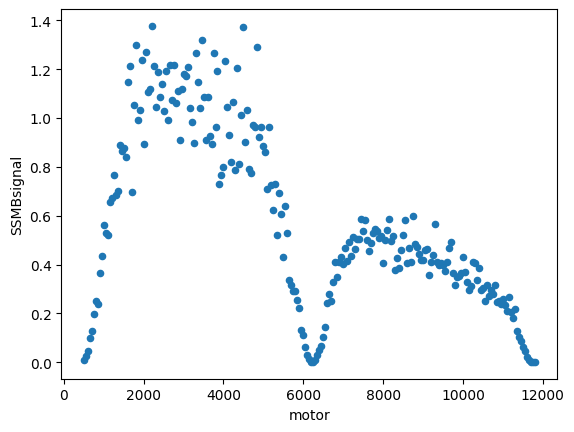

In [9]:
resultdf.plot(x='motor', y='SSMBsignal', kind='scatter')

In [25]:
def powersin(s):
    return np.sin(np.pi*(s-6250)/5500 )**2

Text(0, 0.5, 'coherent radiation signal / mV')

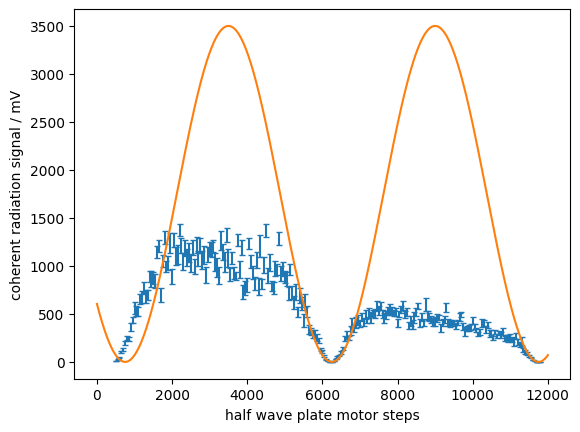

In [31]:
xr = np.linspace(0,12000,1000)

plt.errorbar(resultdf['motor'], resultdf['SSMBsignal']*1000, resultdf['SSMBerror']*1000, ls='none', marker='', capsize=2)
plt.plot(xr, powersin(xr)*3500)
# plt.xlim(5500,7000)
# plt.ylim(0,500)
plt.xlabel('half wave plate motor steps')
plt.ylabel('coherent radiation signal / mV')

Text(0, 0.5, 'coherent radiation signal / mV')

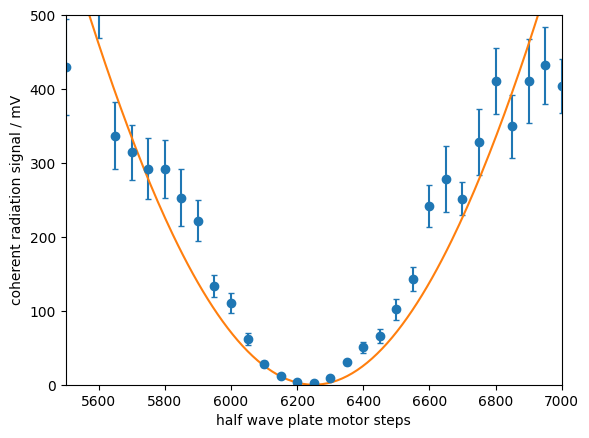

In [30]:
xr = np.linspace(5500,7000,200)

plt.errorbar(resultdf['motor'], resultdf['SSMBsignal']*1000, resultdf['SSMBerror']*1000, ls='none', marker='o', capsize=2)
plt.plot(xr, powersin(xr)*3500)
plt.xlim(5500,7000)
plt.ylim(0,500)
plt.xlabel('half wave plate motor steps')
plt.ylabel('coherent radiation signal / mV')

Text(0, 0.5, 'coherent radiation signal / mV')

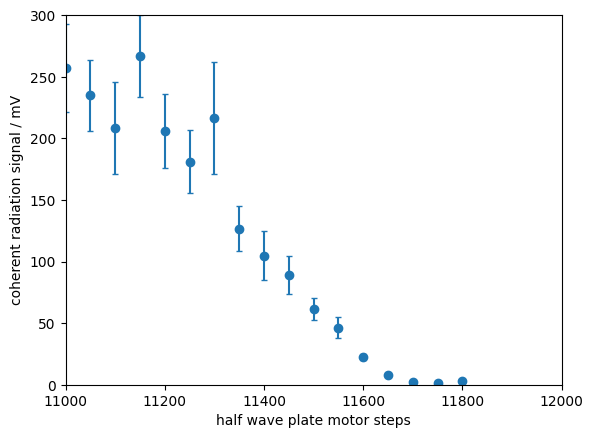

In [22]:
plt.errorbar(resultdf['motor'], resultdf['SSMBsignal']*1000, resultdf['SSMBerror']*1000, ls='none', marker='o', capsize=2)
plt.xlim(11000,12000)
plt.ylim(0,300)
plt.xlabel('half wave plate motor steps')
plt.ylabel('coherent radiation signal / mV')

In [20]:
SSMBlaser.get()

nan